# 01 — APOGEE Eos figures (reference code applied to OUR data)

This notebook applies Belokurov's `eos-figures` code (cloned into `../eos-figures`) to
**our own APOGEE catalogues** (`APOGEE_DR17_all.fits` + `apogee_astroNN-DR17.fits`),
built into a matched cache with their `build_cache`, then run through their exact
cuts (`eos_figures.config.Cuts`), population masks (`eos_figures.data.make_masks`),
and plotting helpers.

Verification: on our data the population counts match the reference cache to ~0.1%
(base 210,205 vs 210,392; accreted 2,572 vs 2,584; low-α 142,909 vs 143,018), so we
reproduce the published figures from our own data.

Key cuts (all from their `Cuts`):
- **base sample**: `logg < 3.0`, per-component velocity errors `< 50`, chemical errors
  `< 0.2` on ten elements, satellite removal, drop MagClouds — not a loose giant band.
- **accreted** is chemistry **plus** an energy–Lz box (`E > -2e5`, `|Lz| < 500`).
- **low-α (thin)** adds the `[Al/Fe] < 0.9[Fe/H] + 0.9` anti-contamination diagonal.
- line coefficients: accreted `[Mg/Fe] = -0.30[Fe/H] - 0.10`, high/low-α `= -0.14[Fe/H] + 0.135`.

Figures are saved to `../figures_repro/` as PNGs as well as shown inline.


## Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# drive everything off the reference implementation
REPO = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/eos-figures')
sys.path.insert(0, str(REPO))

# numpy>=2 removed np.trapz (kde_curve still calls it) -> restore alias
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

from eos_figures.config import Cuts
from eos_figures.data import load_catalog, make_masks
from eos_figures.stats import (hist2d, stat2d, bin_percentile, finite_percentile,
                               kde_curve, log_image)
from eos_figures.plotting import (setup_axes, density_panel, value_panel,
                                  smoothed_scatter_panel, label_axes)
from eos_figures.figures import _idl_low_density_mask

# where our figures get saved so they are easy to open
FIGDIR = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/figures_repro')
FIGDIR.mkdir(exist_ok=True)
print('reference repo:', REPO)
print('figures ->', FIGDIR)

reference repo: /Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/eos-figures
figures -> /Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/figures_repro


## Load OUR matched cache and build masks

In [2]:
# cache built from our APOGEE_DR17_all.fits + apogee_astroNN-DR17.fits via build_cache
OUR_CACHE = Path('/Users/hanyuan/Library/CloudStorage/Dropbox/python_script/EoS_explore/data_repro/our_apogee_dr17_lite_ann.fits.gz')
cat = load_catalog(OUR_CACHE)
c   = Cuts()
m   = make_masks(cat, c)

print(f'catalogue rows : {len(cat):,}')
print(f'  base                : {int(m["base"].sum()):,}')
print(f'  accreted (chem+kin) : {int(m["acc"].sum()):,}')
print(f'  high-alpha (thick)  : {int(m["thick"].sum()):,}')
print(f'  low-alpha  (thin)   : {int(m["thin"].sum()):,}')
print(f'  low-alpha Al-clean  : {int(m["thin_al"].sum()):,}')
print(f'  high-alpha Al-clean : {int(m["thick_al"].sum()):,}')

catalogue rows : 529,044
  base                : 210,205
  accreted (chem+kin) : 2,572
  high-alpha (thick)  : 60,458
  low-alpha  (thin)   : 142,909
  low-alpha Al-clean  : 141,189
  high-alpha Al-clean : 60,247


## Figure 1 — Energy–Lz, [Mg/Fe]–[Fe/H], [Al/Fe]–[Fe/H]
Base sample. The dashed line is the accreted/in-situ split, the dotted line the
high-α/low-α split; the horizontal dashed line in Al is the in-situ cut.

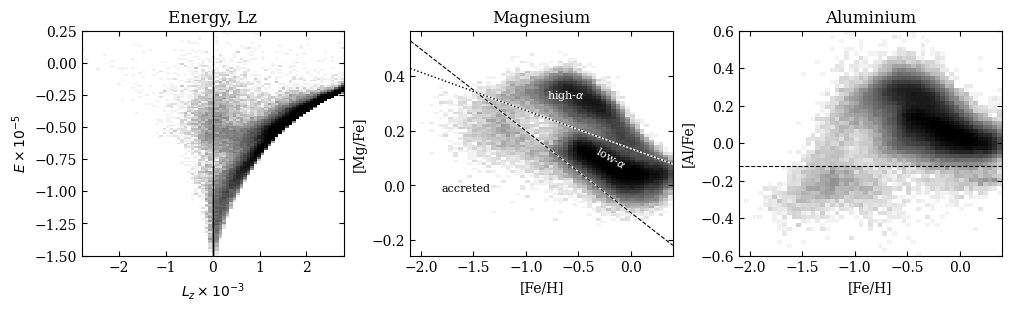

In [3]:
fig, ax = setup_axes(3, figsize=(10, 3))

h, xe, ye = hist2d(cat["lz"][m["base"]], 1e-5 * cat["energy"][m["base"]], c.lzr, c.enr, c.nlz, c.nen)
density_panel(ax[0], h, xe * 1e-3, ye, percentiles=(1, 95), vmin=-0.3)
ax[0].axvline(0, color="k", lw=0.8)
label_axes(ax[0], r"$L_z\times 10^{-3}$", r"$E\times 10^{-5}$", "Energy, Lz")

h, xe, ye = hist2d(cat["fe_h"][m["base"]], cat["mg_fe"][m["base"]], c.fehr, c.mgfer, c.nfeh, c.nmg)
density_panel(ax[1], h, xe, ye, percentiles=(2, 98))
xx = np.array(c.fehr)
ax[1].plot(xx, c.slope_acc * xx + c.inter_acc, "w-", lw=1.1)
ax[1].plot(xx, c.slope_acc * xx + c.inter_acc, "k--", lw=0.8)
ax[1].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "w-", lw=1.1)
ax[1].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "k:", lw=1.0)
ax[1].text(-1.8, -0.02, "accreted", fontsize=8)
ax[1].text(-0.8, 0.32, r"high-$\alpha$", color="w", fontsize=8)
ax[1].text(-0.35, 0.06, r"low-$\alpha$", color="w", fontsize=8, rotation=-30)
label_axes(ax[1], "[Fe/H]", "[Mg/Fe]", "Magnesium")

h, xe, ye = hist2d(cat["fe_h"][m["base"]], cat["al_fe"][m["base"]], c.fehr, c.alfer, c.nfeh, c.nal)
density_panel(ax[2], h, xe, ye, percentiles=c.perc1)
ax[2].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
label_axes(ax[2], "[Fe/H]", "[Al/Fe]", "Aluminium")
fig.savefig(FIGDIR / '01_fig1_energy_mg_al.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — [Al/Fe]–[Fe/H] for the three populations
Top: column-normalised density. Bottom: same bins coloured by median $V_{\rm tan}$.
Eos appears as the low-$V_{\rm tan}$ (halo) tail of the low-α panel.

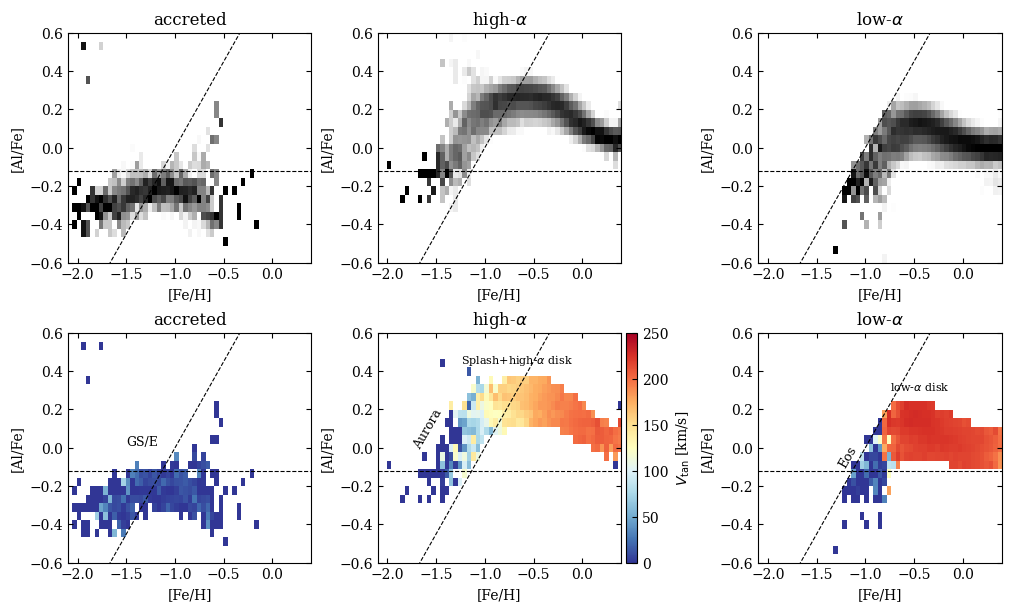

In [4]:
fig, ax = setup_axes(3, nrows=2, figsize=(10, 6))
specs = [("acc", "accreted", c.perc),
         ("thick", r"high-$\alpha$", c.perc2),
         ("thin", r"low-$\alpha$", c.perc2)]
hist_cache, mask_cache = {}, {}
for i, (mask_name, title, perc) in enumerate(specs):
    h, xe, ye = hist2d(cat["fe_h"][m[mask_name]], cat["al_fe"][m[mask_name]], c.fehr, c.alfer, c.nfeh, c.nal2, normalize="x")
    hist_cache[mask_name] = (h, xe, ye)
    mask_cache[mask_name] = _idl_low_density_mask(h, perc, c.white_lim)
    density_panel(ax[i], h, xe, ye, percentiles=perc)
    ax[i].plot(c.fehr, np.array(c.fehr) * c.kalfe + c.offalfe, "k--", lw=0.8)
    ax[i].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
    ax[i].set_xlim(c.fehr); ax[i].set_ylim(c.alfer)
    label_axes(ax[i], "[Fe/H]", "[Al/Fe]", title)

for i, (mask_name, title, _) in enumerate(specs, start=3):
    h, xe, ye = hist_cache[mask_name]
    vmask = (m[mask_name] & np.isfinite(cat["galvt"])
             & (cat["galvt"] >= c.vtanr[0]) & (cat["galvt"] <= c.vtanr[1]))
    med, _, _ = stat2d(cat["fe_h"][vmask], cat["al_fe"][vmask], cat["galvt"][vmask], c.fehr, c.alfer, c.nfeh, c.nal2)
    h_med, _, _ = hist2d(cat["fe_h"][vmask], cat["al_fe"][vmask], c.fehr, c.alfer, c.nfeh, c.nal2)
    med = np.nan_to_num(med, nan=0.0); med[h_med <= 2] = 0.0
    value_panel(ax[i], med, xe, ye, *c.mm_vtan, mask=mask_cache[mask_name],
                cmap="RdYlBu_r", colorbar_label=r"$V_{\rm tan}$ [km/s]" if i == 4 else None)
    ax[i].plot(c.fehr, np.array(c.fehr) * c.kalfe + c.offalfe, "k--", lw=0.8)
    ax[i].axhline(c.alfe_cut, color="k", ls="--", lw=0.8)
    ax[i].set_xlim(c.fehr); ax[i].set_ylim(c.alfer)
    label_axes(ax[i], "[Fe/H]", "[Al/Fe]", title)
ax[3].text(-1.5, 0.01, "GS/E", fontsize=9)
ax[4].text(-1.75, 0.0, "Aurora", fontsize=9, rotation=60)
ax[4].text(-1.25, 0.44, r"Splash+high-$\alpha$ disk", fontsize=8)
ax[5].text(-1.3, -0.1, "Eos", fontsize=9, rotation=60)
ax[5].text(-0.75, 0.3, r"low-$\alpha$ disk", fontsize=8)
fig.savefig(FIGDIR / '01_fig2_alfe_pops.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Energy–Lz of the three populations
Validation: the **Eos** clump sits at $|L_z|\approx0$, $E\times10^{-5}\approx-0.55$ in the low-α panel.

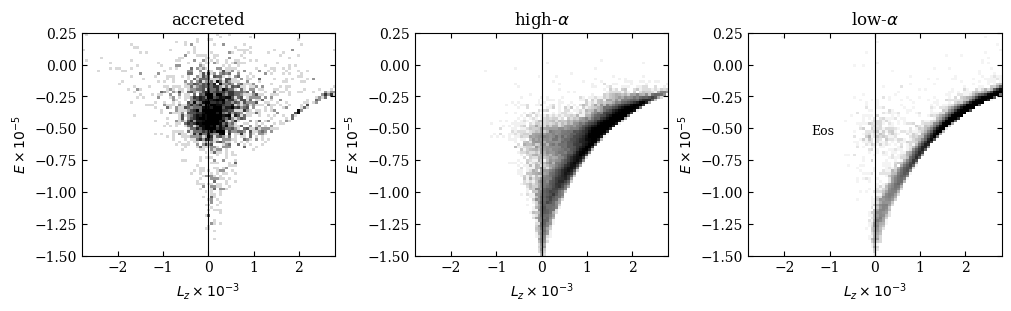

In [5]:
fig, ax = setup_axes(3, figsize=(10, 3))
for axis, mask_name, title in zip(ax, ["acc_al", "thick_al", "thin_al"],
                                  ["accreted", r"high-$\alpha$", r"low-$\alpha$"]):
    h, xe, ye = hist2d(cat["lz"][m[mask_name]], 1e-5 * cat["energy"][m[mask_name]], c.lzr, c.enr, c.nlz2, c.nen2)
    density_panel(axis, h, xe * 1e-3, ye, percentiles=c.perc_elz, vmin=-0.3)
    axis.axvline(0, color="k", lw=0.8)
    label_axes(axis, r"$L_z\times 10^{-3}$", r"$E\times 10^{-5}$", title)
ax[2].text(-1.4, -0.55, "Eos", fontsize=9)
fig.savefig(FIGDIR / '01_fig3_energy_pops.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — [Mg/Fe] column-density, mean [Al/Fe], and the $-0.8<$[Fe/H]$<-0.6$ triangle
The right panel resolves three clumps in [Al/Fe]–[Mg/Fe]: high-α disc, GS/E, and Eos.

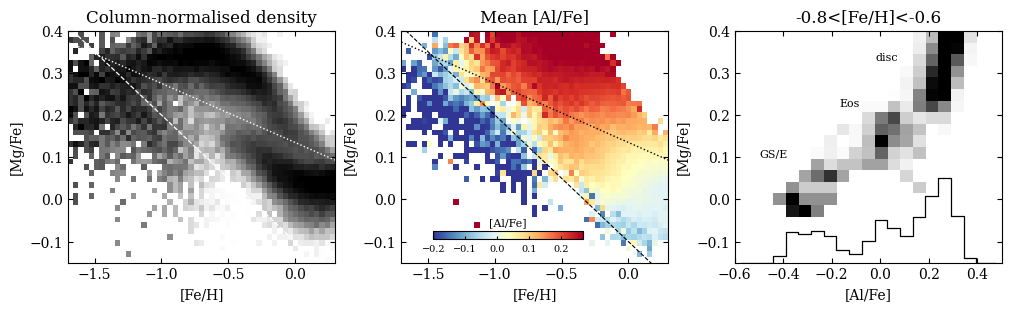

In [6]:
fig, ax = setup_axes(3, figsize=(10, 3))
h0, xe, ye = hist2d(cat["fe_h"][m["base_en"]], cat["mg_fe"][m["base_en"]], c.fehr2, c.mgfer2, c.nfeh2, c.nmg2)
h, _, _ = hist2d(cat["fe_h"][m["base_en"]], cat["mg_fe"][m["base_en"]], c.fehr2, c.mgfer2, c.nfeh2, c.nmg2, normalize="x")
density_panel(ax[0], h, xe, ye, percentiles=c.perc_mgfe)
xx = np.array(c.fehr2)
ax[0].plot(xx, c.slope_acc * xx + c.inter_acc, "w--", lw=0.9)
ax[0].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "w:", lw=1.0)
ax[0].set_xlim(c.fehr2); ax[0].set_ylim(c.mgfer2)
label_axes(ax[0], "[Fe/H]", "[Mg/Fe]", "Column-normalised density")

mean_al, xe, ye = stat2d(cat["fe_h"][m["base_en"]], cat["mg_fe"][m["base_en"]], cat["al_fe"][m["base_en"]], c.fehr2, c.mgfer2, c.nfeh2, c.nmg2, statistic="mean")
im_mid = value_panel(ax[1], mean_al, xe, ye, -0.2, 0.27, mask=h0 <= 1, cmap="RdYlBu_r")
cax = ax[1].inset_axes([0.12, 0.10, 0.56, 0.035])
cb = fig.colorbar(im_mid, cax=cax, orientation="horizontal"); cb.set_label("[Al/Fe]", fontsize=8)
cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks_position("bottom"); cb.ax.tick_params(labelsize=7, length=2)
ax[1].plot(xx, c.slope_acc * xx + c.inter_acc, "k--", lw=0.8)
ax[1].plot(xx, c.slope_acc2 * xx + c.inter_acc2, "k:", lw=1.0)
ax[1].set_xlim(c.fehr2); ax[1].set_ylim(c.mgfer2)
label_axes(ax[1], "[Fe/H]", "[Mg/Fe]", "Mean [Al/Fe]")

h0, xe, ye = hist2d(cat["al_fe"][m["tri"]], cat["mg_fe"][m["tri"]], c.alfer2, c.mgfer2, 21, 20)
h, _, _ = hist2d(cat["al_fe"][m["tri"]], cat["mg_fe"][m["tri"]], c.alfer2, c.mgfer2, 21, 20, normalize="y")
mm = finite_percentile(h[h > 0], (35, 93))
scaled = 255 * np.clip((h - mm[0]) / (mm[1] - mm[0]), 0, 1)
scaled[h0 <= 1] = np.nan
ax[2].imshow(scaled.T, origin="lower", extent=[xe[0], xe[-1], ye[0], ye[-1]],
             aspect="auto", interpolation="nearest", cmap="Greys", vmin=0, vmax=255)
prof = np.nansum(scaled, axis=1)
if np.nanmax(prof) > 0:
    xcent = 0.5 * (xe[:-1] + xe[1:]); yprof = c.mgfer2[0] + 0.2 * prof / np.nanmax(prof)
    ax[2].step(xcent, yprof, where="mid", color="k", lw=0.9)
ax[2].text(-0.5, 0.1, "GS/E", fontsize=8); ax[2].text(-0.17, 0.22, "Eos", fontsize=8); ax[2].text(-0.02, 0.33, "disc", fontsize=8)
ax[2].set_xlim(c.alfer2); ax[2].set_ylim(c.mgfer2)
label_axes(ax[2], "[Al/Fe]", "[Mg/Fe]", f"{c.feh_tri_cut[0]:.1f}<[Fe/H]<{c.feh_tri_cut[1]:.1f}")
fig.savefig(FIGDIR / '01_fig4_alfe_3pops.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 5 — $V_{\rm tan}$ vs [Fe/H] for low-α, coloured by $r_{\rm apo}$, $r_{\rm peri}$, age
Eos is the low-α population extending to $V_{\rm tan}\approx0$ with large $r_{\rm apo}$.

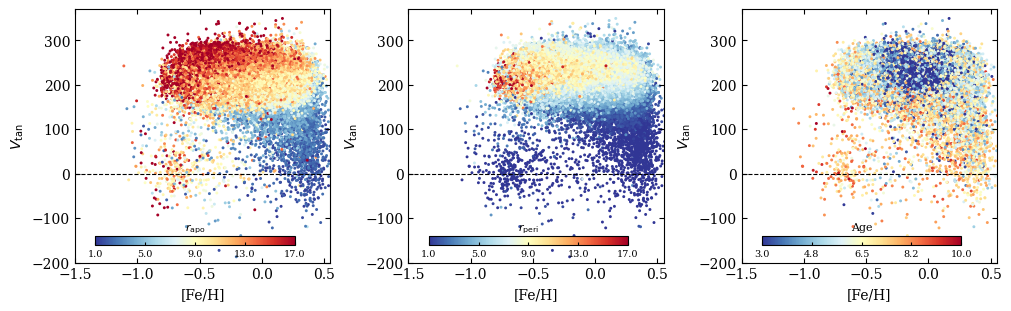

In [7]:
fig, ax = setup_axes(3, figsize=(10, 3))
panels = [(m["thin_al"], cat["rap"], c.mm_rapo, r"$r_{\rm apo}$", np.linspace(c.mm_rapo[0], c.mm_rapo[1], 5)),
          (m["thin_al"], cat["rperi"], c.mm_rperi, r"$r_{\rm peri}$", np.linspace(c.mm_rperi[0], c.mm_rperi[1], 5)),
          (m["thin_al_age"], cat["age"], c.mm_age, "Age", np.linspace(c.mm_age[0], c.mm_age[1], 5))]
for axis, (mask, color, mm, label, ticks) in zip(ax, panels):
    clipped = np.clip(color[mask], mm[0], mm[1])
    sc = smoothed_scatter_panel(axis, cat["fe_h"][mask], cat["galvt"][mask], clipped,
                                c.fehr_plot, c.vphir_plot2, cmap="RdYlBu_r", vmin=mm[0], vmax=mm[1],
                                s=4.5, sort_by_color=False)
    axis.axhline(0, color="k", ls="--", lw=0.8)
    axis.set_xlim(c.fehr_plot); axis.set_ylim(c.vphir_plot2)
    axis.set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5]); axis.set_yticks([-200, -100, 0, 100, 200, 300])
    cax = axis.inset_axes([0.08, 0.07, 0.78, 0.035])
    cb = fig.colorbar(sc, cax=cax, orientation="horizontal"); cb.set_label(label, fontsize=8)
    cb.set_ticks(ticks); cb.set_ticklabels([f"{t:.1f}" for t in ticks])
    cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks_position("bottom"); cb.ax.tick_params(labelsize=7, length=2)
    label_axes(axis, "[Fe/H]", r"$V_{\rm tan}$")
fig.savefig(FIGDIR / '01_fig5_vphi.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 6 — Ages
Left: age–[Fe/H] tracks (low-α vs high-α). Middle: low-α, $V_{\rm tan}<80$, coloured by $r_{\rm apo}$.
Right: age distributions of Eos, Splash, and the low-α disc — the Splash≈Eos match is the key result.

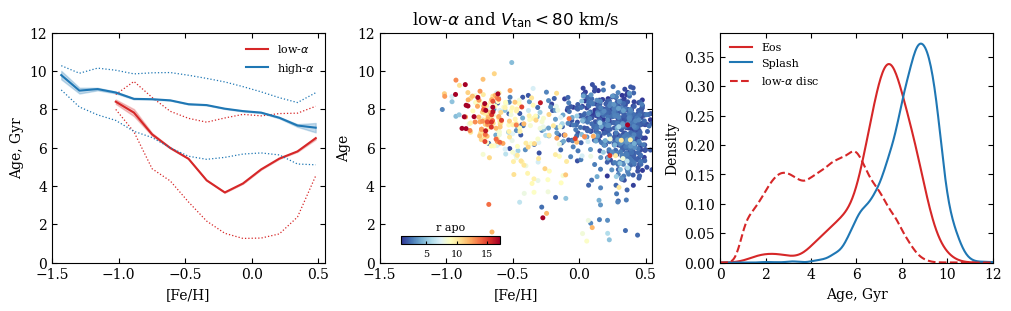

In [8]:
fig, ax = setup_axes(3, figsize=(10, 3))
for mask_name, color, label in [("thin_al_age", "tab:red", r"low-$\alpha$"), ("thick_age", "tab:blue", r"high-$\alpha$")]:
    xcen, _, med, std, n = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 50)
    _, _, p5, _, _  = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 5)
    _, _, p95, _, _ = bin_percentile(cat["fe_h"][m[mask_name]], cat["age"][m[mask_name]], c.fehr_plot, c.nbins_age, 95)
    err = np.divide(std, np.sqrt(n), out=np.full_like(std, np.nan), where=n > 0)
    good = np.isfinite(med)
    ax[0].fill_between(xcen[good], med[good] - err[good], med[good] + err[good], color=color, alpha=0.25)
    ax[0].plot(xcen, med, color=color, label=label)
    ax[0].plot(xcen, p5, color=color, ls=":", lw=0.9); ax[0].plot(xcen, p95, color=color, ls=":", lw=0.9)
ax[0].set_xlim(c.fehr_plot); ax[0].set_ylim(c.ager); ax[0].legend(frameon=False, fontsize=8)
label_axes(ax[0], "[Fe/H]", "Age, Gyr")

sc = smoothed_scatter_panel(ax[1], cat["fe_h"][m["thin_al_vt_age"]], cat["age"][m["thin_al_vt_age"]],
                            cat["rap"][m["thin_al_vt_age"]], c.fehr_plot, c.ager, cmap="RdYlBu_r",
                            vmin=c.mm_rapo[0], vmax=c.mm_rapo[1], s=13)
ax[1].set_xlim(c.fehr_plot); ax[1].set_ylim(c.ager)
cax = ax[1].inset_axes([0.08, 0.08, 0.36, 0.035])
cb = fig.colorbar(sc, cax=cax, orientation="horizontal"); cb.set_label("r apo", fontsize=8)
cb.ax.xaxis.set_label_position("top"); cb.ax.xaxis.set_ticks_position("bottom"); cb.ax.tick_params(labelsize=7, length=2)
label_axes(ax[1], "[Fe/H]", "Age", r"low-$\alpha$ and $V_{\rm tan}<80$ km/s")

for mask_name, color, label, ls in [("thin_al_vt_rap_age", "tab:red", "Eos", "-"),
                                    ("thick_al_splash_age", "tab:blue", "Splash", "-"),
                                    ("thin_al_age", "tab:red", r"low-$\alpha$ disc", "--")]:
    x, y = kde_curve(cat["age"][m[mask_name]], c.ager)
    ax[2].plot(x, y, color=color, ls=ls, label=label)
ax[2].set_xlim(c.ager); ax[2].set_ylim(0, None); ax[2].legend(frameon=False, fontsize=8)
label_axes(ax[2], "Age, Gyr", "Density")
fig.savefig(FIGDIR / '01_fig6_age.png', dpi=150, bbox_inches='tight')
plt.show()